In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# --- Carregar Tabelas 5 ---
t2012 = pd.read_csv(
    r"H:\3etapa_Py\aula5\Tabela5-sem_emprego_2012 - Tabela5-sem_emprego_2012.csv",
    decimal=",",
)
t2026 = pd.read_csv(
    r"H:\3etapa_Py\aula5\Tabela5-sem_emprego_2026 - Tabela5-sem_emprego_2026.csv",
    decimal=",",
)

# Renomear colunas para facilitar o merge
t2012 = t2012.rename(columns={
    "Desocupados - homens (2012 T1)": "homens_2012",
    "Desocupados - mulheres (2012 T1)": "mulheres_2012",
})
t2026 = t2026.rename(columns={
    "Desocupados - homens (2026 T1)": "homens_2026",
    "Desocupados - mulheres (2026 T1)": "mulheres_2026",
})

# Juntar as duas tabelas
comp = t2012.merge(t2026, on=["Sigla", "Código", "Estado"], how="inner")
comp

,Sigla,Código,Estado,homens_2012,mulheres_2012,homens_2026,mulheres_2026
0,AC,12,Acre,45.3,54.7,53.2,46.8
1,AL,27,Alagoas,44.7,55.3,50.7,49.3
2,AM,13,Amazonas,47.5,52.5,46.8,53.2
3,AP,16,Amapá,48.1,51.9,51.1,48.9
4,BA,29,Bahia,43.8,56.2,44.7,55.3
5,CE,23,Ceará,51.1,48.9,52.7,47.3
6,DF,53,Distrito Federal,41.0,59.0,47.9,52.1
7,ES,32,Espírito Santo,46.4,53.6,47.5,52.5
8,GO,52,Goiás,41.0,59.0,47.5,52.5
9,MA,21,Maranhão,47.2,52.8,49.1,50.9


In [5]:

path_tab1 = r"H:\3etapa_Py\aula2\Tabela 1.1.1 - Copia.xls"
bruto = pd.read_excel(path_tab1, engine="xlrd", header=None)

indicador_1 = bruto.iloc[8:41].copy()
indicador_1.columns = [
    "uf_regiao", "total", "total_branca", "total_preta_parda",
    "homem_branca", "homem_preta_parda", "mulher_branca", "mulher_preta_parda",
]
indicador_1 = indicador_1.reset_index(drop=True)
for col in indicador_1.columns[1:]:
    indicador_1[col] = pd.to_numeric(indicador_1[col], errors="coerce")


nao_estados = ["Brasil", "Norte", "Nordeste", "Sudeste", "Sul", "Centro-Oeste"]
tab1_estados = indicador_1[~indicador_1["uf_regiao"].isin(nao_estados)].reset_index(drop=True)
tab1_estados

,uf_regiao,total,total_branca,total_preta_parda,homem_branca,homem_preta_parda,mulher_branca,mulher_preta_parda
0,Rondônia,17.014162,16.727733,17.101523,12.111127,12.544080,20.412887,21.061410
1,Acre,13.606903,13.806929,13.541399,10.796120,9.686983,16.130352,16.710754
2,Amazonas,16.807290,15.987545,16.995493,12.233043,12.822584,18.764969,20.716986
3,Roraima,13.639257,13.651755,13.633606,10.814803,10.476601,16.135877,16.560244
4,Pará,16.474268,16.181627,16.560239,11.524306,11.026707,19.835110,21.591144
5,Amapá,13.586656,14.389180,13.415091,11.116821,10.749444,16.648579,15.908487
6,Tocantins,15.815781,15.701788,15.768728,10.733863,11.682616,19.663713,19.629399
7,Maranhão,16.669614,16.421773,16.708894,11.665173,11.437359,19.881056,20.739589
8,Piauí,17.960366,16.948094,18.231789,12.258324,11.204814,20.494063,23.695440
9,Ceará,19.499293,18.527120,19.882469,12.186936,12.821323,23.019718,24.952274


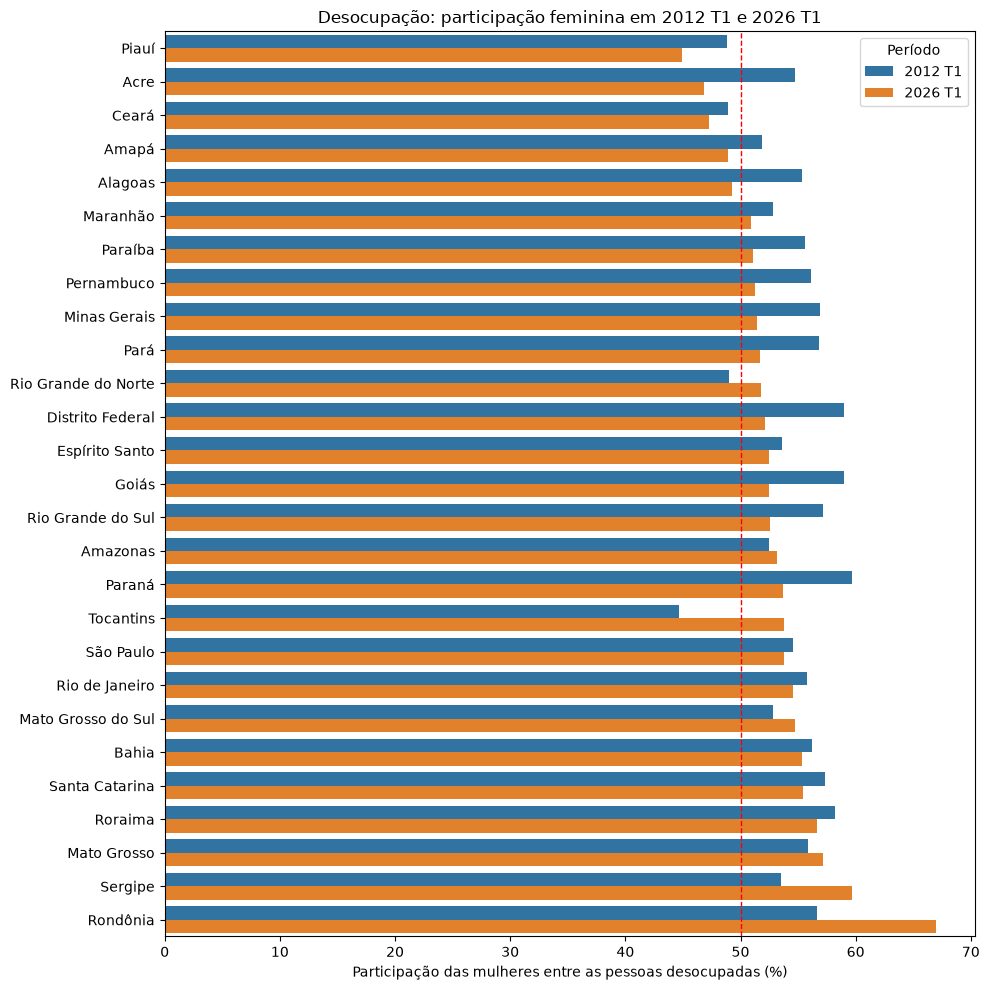

In [6]:


ordem = comp.sort_values("mulheres_2026")["Estado"]


longo = comp.melt(
    id_vars=["Sigla", "Código", "Estado"],
    value_vars=["mulheres_2012", "mulheres_2026"],
    var_name="Ano",
    value_name="Participacao_mulheres",
)
longo["Ano"] = longo["Ano"].map({"mulheres_2012": "2012 T1", "mulheres_2026": "2026 T1"})

fig, ax = plt.subplots(figsize=(10, 10))
sns.barplot(
    data=longo,
    y="Estado",
    x="Participacao_mulheres",
    hue="Ano",
    order=ordem,
    ax=ax,
)
ax.axvline(50, color="red", linestyle="--", linewidth=1)
ax.set_xlabel("Participação das mulheres entre as pessoas desocupadas (%)")
ax.set_ylabel("")
ax.set_title("Desocupação: participação feminina em 2012 T1 e 2026 T1")
ax.legend(title="Período")
fig.tight_layout()
plt.show()